In [1]:
# ==============================
# Intrusion Detection (UNSW-NB15)
# Clean, Fixed, Fully Runnable
# ==============================

# ---- Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

In [2]:
# ---- Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# ---- Data Load
# Optional features file (won't crash if absent)
try:
    NB15_features = pd.read_csv('NUSW-NB15_features.csv', encoding='cp1252')
except Exception as e:
    NB15_features = None

# Main training set
df = pd.read_csv('UNSW_NB15_training-set.csv')


In [4]:
print("Columns:", list(df.columns))
print(df.info())
print(df.describe(include='all'))

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332

In [5]:
# ---- Basic Cleaning
print("\nMissing values per column (before dropna):\n", df.isna().sum())
df.dropna(inplace=True)
print("Remaining missing values (after dropna):", df.isna().sum().sum())


Missing values per column (before dropna):
 id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst  

In [6]:
# Drop id if present
if 'id' in df.columns:
    df.drop(['id'], axis=1, inplace=True)

# Normalize placeholder values
if 'state' in df.columns:
    df['state'] = df['state'].replace('-', 'other')
if 'service' in df.columns:
    df['service'] = df['service'].replace('-', 'other')

In [7]:
# Harmonize attack category spelling if present
if 'attack_cat' in df.columns:
    df['attack_cat'] = df['attack_cat'].apply(lambda x: 'Backdoor' if x == 'Backdoors' else x)

# ---- EDA (safe)
# Pie of labels (binary target 0/1)
if 'label' in df.columns:
    counts = df['label'].value_counts()
    fig = px.pie(values=counts.values, names=counts.index, title='Distribution of Label')
    fig.show()

In [8]:
# Bar of attack categories (excluding 'normal'), if column exists
if 'attack_cat' in df.columns:
    attack_by_cat = df[df['attack_cat'] != 'normal'].groupby('attack_cat').size().reset_index(name='counts')
    if not attack_by_cat.empty:
        fig = px.bar(attack_by_cat.sort_values(by='counts', ascending=False),
                     x='attack_cat', y='counts', title='Distribution of Attack Categories')
        fig.show()

In [9]:
# KDE of sbytes (ensure positive for log-scale)
for col in ['sbytes']:
    if col in df.columns:
        # cast numeric
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        # avoid log-scale crash
        df.loc[df[col] <= 0, col] = 1

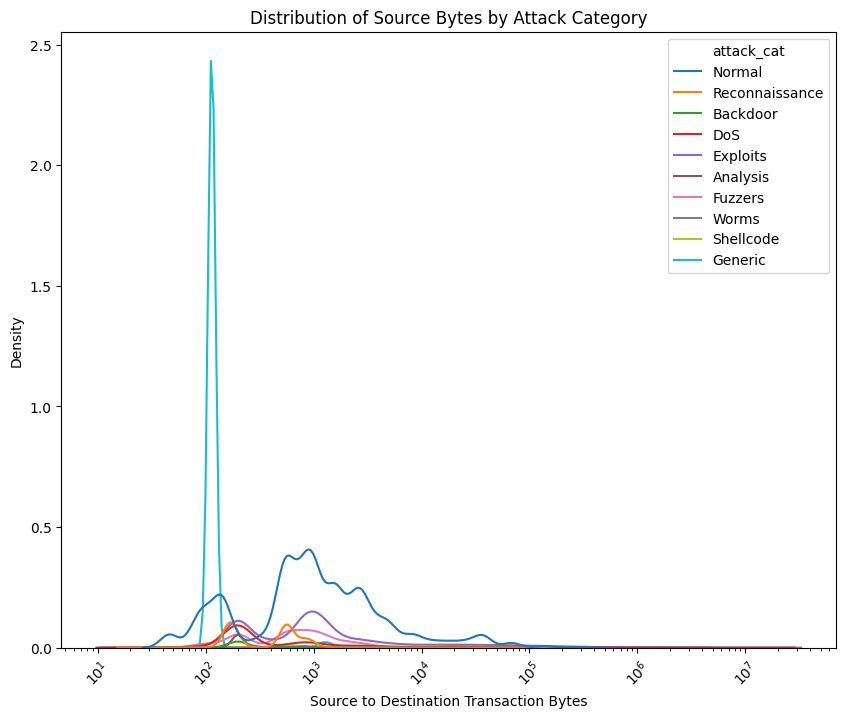

In [10]:

if {'sbytes', 'attack_cat'}.issubset(df.columns):
    plt.figure(figsize=(10, 8))
    ax = sns.kdeplot(
        x='sbytes',
        hue='attack_cat',
        log_scale=True,
        data=df[df['attack_cat'] != 'normal']
    )
    ax.set_title('Distribution of Source Bytes by Attack Category')
    ax.set_xlabel('Source to Destination Transaction Bytes')
    ax.set_ylabel('Density')
    plt.xticks(rotation=45)
    plt.show()

# Subplots: service usage by attack categories (safe colors, safe layout)
if {'attack_cat', 'service'}.issubset(df.columns):
    df_attacks_cat_services = (
        df[df['attack_cat'] != 'normal']
        .groupby(['attack_cat', 'service'])
        .size()
        .reset_index(name='Count')
    )

    categories = ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers',
                  'Generic', 'Reconnaissance', 'Shellcode', 'Worms']

    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=[f"Category: {cat}" for cat in categories]
    )
    positions = [(r, c) for r in range(1, 4) for c in range(1, 4)]

    for i, category in enumerate(categories):
        df_filtered = df_attacks_cat_services[df_attacks_cat_services['attack_cat'] == category]
        fig.add_trace(
            go.Bar(
                x=df_filtered['service'],
                y=df_filtered['Count'],
                name=category
            ),
            row=positions[i][0],
            col=positions[i][1]
        )

    fig.update_layout(
        height=900,
        width=1000,
        title_text="Service Counts by Attack Categories",
        showlegend=False
    )
    fig.update_xaxes(tickangle=90)
    fig.show()


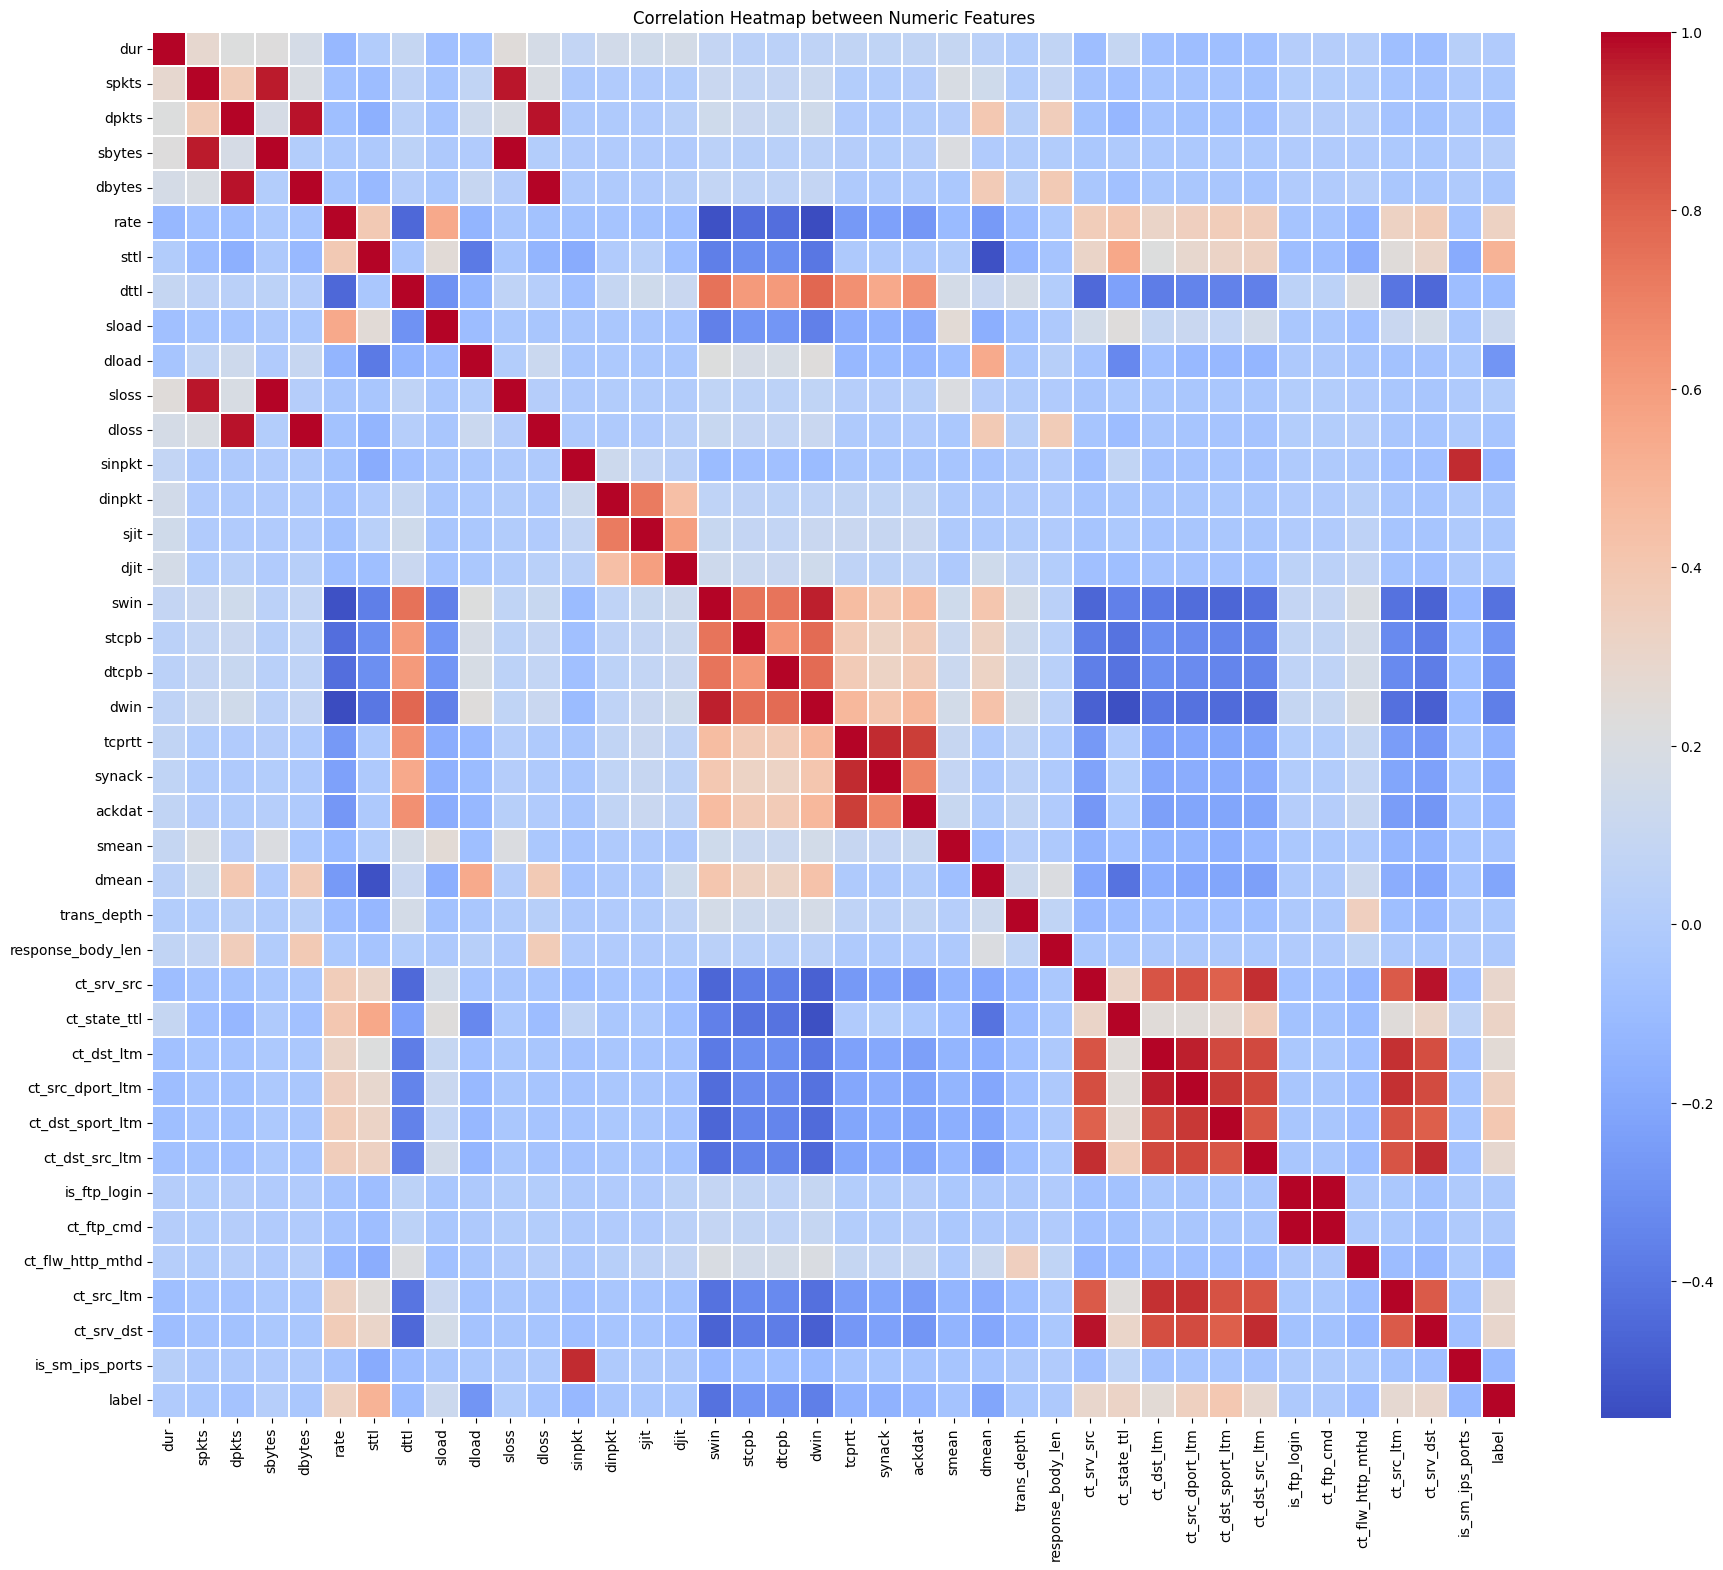

In [11]:
# ---- Correlation (numeric only), safe
numerical_columns = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
if numerical_columns:
    corr = df[numerical_columns].corr()
    plt.figure(figsize=(22, 18))
    sns.heatmap(corr, cmap='coolwarm', linewidths=0.2, annot=False)
    plt.title('Correlation Heatmap between Numeric Features')
    plt.show()

# ---- Drop highly correlated (only if exist)
features_to_drop = ['ct_state_ttl', 'ct_dst_sport_ltm', 'ct_src_ltm']
existing_to_drop = [c for c in features_to_drop if c in df.columns]
if existing_to_drop:
    df.drop(existing_to_drop, axis=1, inplace=True)

In [12]:

# ---- Encoding categoricals
# One-hot for proto, service if exist
for cat_col in ['proto', 'service']:
    if cat_col in df.columns:
        df = pd.get_dummies(df, columns=[cat_col], drop_first=True)

# Label-encode state, attack_cat if exist
le = LabelEncoder()
for enc_col in ['state', 'attack_cat']:
    if enc_col in df.columns and not pd.api.types.is_numeric_dtype(df[enc_col]):
        df[enc_col] = le.fit_transform(df[enc_col].astype(str))



In [13]:
# ---- Feature Engineering (guarded)
def safe_ratio(a, b):
    return a / (b + 1)

for col in ['sload', 'dload', 'sbytes', 'dbytes', 'spkts', 'dpkts',
            'sttl', 'dttl', 'sjit', 'djit', 'synack', 'ackdat']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

if {'sload', 'dload'}.issubset(df.columns):
    df['load_interaction'] = df['sload'] * df['dload']

if {'sbytes', 'dbytes'}.issubset(df.columns):
    df['total_bytes'] = df['sbytes'] + df['dbytes']
    df['bytes_diff']  = df['sbytes'] - df['dbytes']
    df['bytes_ratio'] = safe_ratio(df['sbytes'], df['dbytes'])

if {'spkts', 'dpkts'}.issubset(df.columns):
    df['pkt_flow_ratio'] = safe_ratio(df['spkts'], df['dpkts'])

if {'sttl', 'dttl'}.issubset(df.columns):
    df['ttl_diff'] = df['sttl'] - df['dttl']

if {'sjit', 'djit'}.issubset(df.columns):
    df['jitter_diff']  = df['sjit'] - df['djit']
    df['jitter_ratio'] = safe_ratio(df['sjit'], df['djit'])

if {'synack', 'ackdat'}.issubset(df.columns):
    df['tcp_time_diff'] = df['synack'] - df['ackdat']

# ---- Train/Test Split
if 'label' not in df.columns:
    raise ValueError("Target column 'label' not found in the dataset.")



In [14]:
X = df.drop(columns=['label'])
y = df['label'].astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)



In [15]:
# ---- Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# TF-friendly dtypes
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
y_train = np.array(y_train, dtype=np.float32)
y_val   = np.array(y_val, dtype=np.float32)

# ---- Reshape for CNN: (batch, timesteps/features, channels=1)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0],   X_val.shape[1],   1)



In [16]:
# ---- CNN builder
def create_cnn_model(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) 
    return model



In [ ]:
# ---- Train 5-model CNN ensemble
cnn_models = []
num_models = 5
EPOCHS = 5
BATCH = 64

for i in range(num_models):
    print(f"\nTraining CNN model {i+1}/{num_models}\n")
    model = create_cnn_model((X_train.shape[1], 1))

    # Optional callbacks
    cb = [
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1)
    ]

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH,
        verbose=1,
        callbacks=cb
    )
    cnn_models.append(model)

print("\n✅ Finished training all CNN models.")

# ---- Ensemble predictions (average probabilities)
probs_list = [m.predict(X_val, verbose=0).reshape(-1) for m in cnn_models]
probs_mean = np.mean(np.vstack(probs_list), axis=0)
y_pred = (probs_mean >= 0.5).astype(int)

# ---- Metrics
acc = accuracy_score(y_val, y_pred)
print(f"\nEnsemble Accuracy: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_val, y_pred, digits=4))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Ensemble)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



Training CNN model 1/5



C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9844 - loss: 0.0453 - val_accuracy: 0.9995 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9993 - loss: 0.0047 - val_accuracy: 0.9999 - val_loss: 4.2091e-04 - learning_rate: 0.0010
Epoch 3/5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9996 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 3.1935e-05 - learning_rate: 0.0010
Epoch 4/5
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9995 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 3.4427e-05 - learning_rate: 0.0010
Epoch 5/5
 536/1030 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9997 - loss: 0.0016